In [ ]:
import pandas as pd
import numpy as np
import math

import matplotlib.pyplot as plt
import seaborn as sns
import squarify

from sklearn import preprocessing
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.manifold import TSNE

from scipy.cluster.hierarchy import linkage, fcluster, dendrogram

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [3]:
def label_rfm_total(score_total):
    if score_total >= 11:
        return 'Très bons clients'
    elif score_total >= 9:
        return 'Bons clients'
    elif score_total == 8:
        return 'Clients tièdes'
    elif score_total == 7:
        return 'Nouveaux clients'
    elif 4 <= score_total <= 6:
        return 'À risque'
    else:
        return 'Inactifs'

In [4]:
def remove_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

In [ ]:
df = pd.read_csv("cleaned_data.csv")
today_date = df['order_date'].max() + pd.Timedelta(days=1)

# RFM

In [17]:
clients_df = df.groupby("customer_unique_id").agg(
    review_score_mean=('review_score', 'mean'),
    order_total_sum=('order_total', 'sum'),
    delay_days_mean=('delay_days', 'mean'),
    last_order_date=('order_date', 'max'),
    order_count=('order_id', 'count')
).reset_index()

In [18]:
clients_df['Recency'] = (today_date - clients_df['last_order_date']).dt.days
clients_df['Monetary'] = clients_df['order_total_sum']
clients_df = clients_df.rename(columns={"order_count":"Frequency"})

clients_df = clients_df.set_index("customer_unique_id", drop=True)

bins = [0, 1, 2, 5, 10, 15]
labels = [1, 2, 3, 4, 5]

clients_df['F_score'] = pd.cut(clients_df['Frequency'], bins=bins, labels=labels, right=True).astype(int)

col_names = ["Recency", "Monetary"]

for i in col_names:
    clients_df[f"{i[0]}_score"] = pd.qcut(clients_df[i], 5, labels=[5,4,3,2,1]).astype(int)

clients_df['RFM_Score'] = clients_df['R_score'] + clients_df['F_score'] + clients_df['M_score']

clients_df['Segment'] = clients_df['RFM_Score'].apply(label_rfm_total)

In [19]:
clients_df['Segment'].value_counts().sort_index()

Segment
Bons clients         18733
Clients tièdes       15284
Inactifs              3470
Nouveaux clients     19345
Très bons clients     3775
À risque             32743
Name: count, dtype: int64

## Analysis RFM

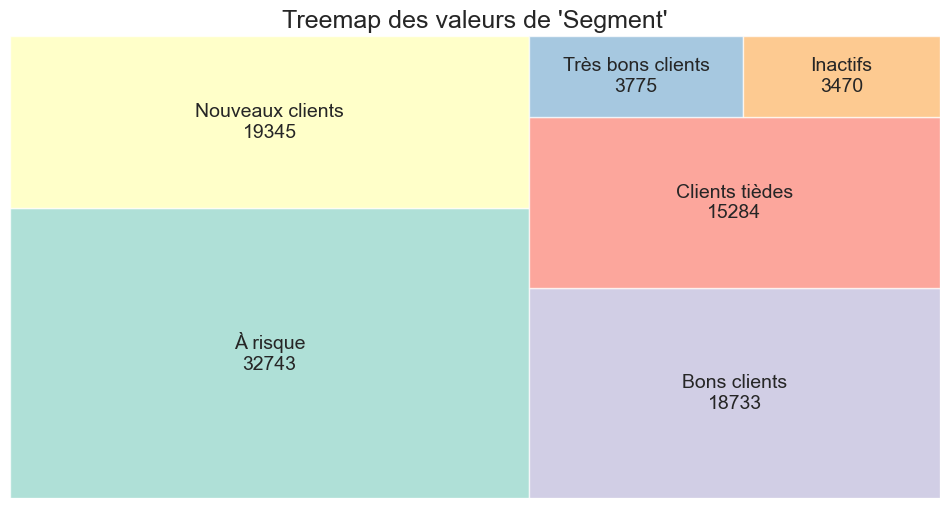

In [ ]:
counts = clients_df['Segment'].value_counts()

plt.figure(figsize=(12, 6))
squarify.plot(
    sizes=counts.values,
    label=[f"{cat}\n{val}" for cat, val in zip(counts.index, counts.values)],
    color=plt.cm.Set3.colors,
    alpha=0.7,
    text_kwargs={'fontsize': 14}
)
plt.title("Treemap des valeurs de 'Segment'", fontsize=18)
plt.axis('off')
plt.show()

In [21]:
def plot_boxplots(df, cols, x_col, order):
    fig, axes = plt.subplots(len(cols), 1, figsize=(10, 5 * len(cols)))
    
    if len(cols) == 1:
        axes = [axes]
    
    for ax, col in zip(axes, cols):
        sns.boxplot(
            data=df,
            x=x_col,
            y=col,
            palette='Set2',
            order=order,
            ax=ax
        )
        ax.set_title(f'Boxplot de {col} par {x_col}')
        ax.set_xlabel(x_col)
        ax.set_ylabel(col)
    
    plt.tight_layout()
    plt.show()

In [22]:
clients_df["Segment"].value_counts().sort_index()

Segment
Bons clients         18733
Clients tièdes       15284
Inactifs              3470
Nouveaux clients     19345
Très bons clients     3775
À risque             32743
Name: count, dtype: int64

In [23]:
numeric_cols = ['delay_days_mean', 'review_score_mean', 'Recency']

df_no_outliers = clients_df.copy()
for col in numeric_cols:
    df_no_outliers = remove_outliers(df_no_outliers, col)

segment_order = ['Très bons clients', "Bons clients", 'Clients tièdes', 'Nouveaux clients', "À risque", "Inactifs"]

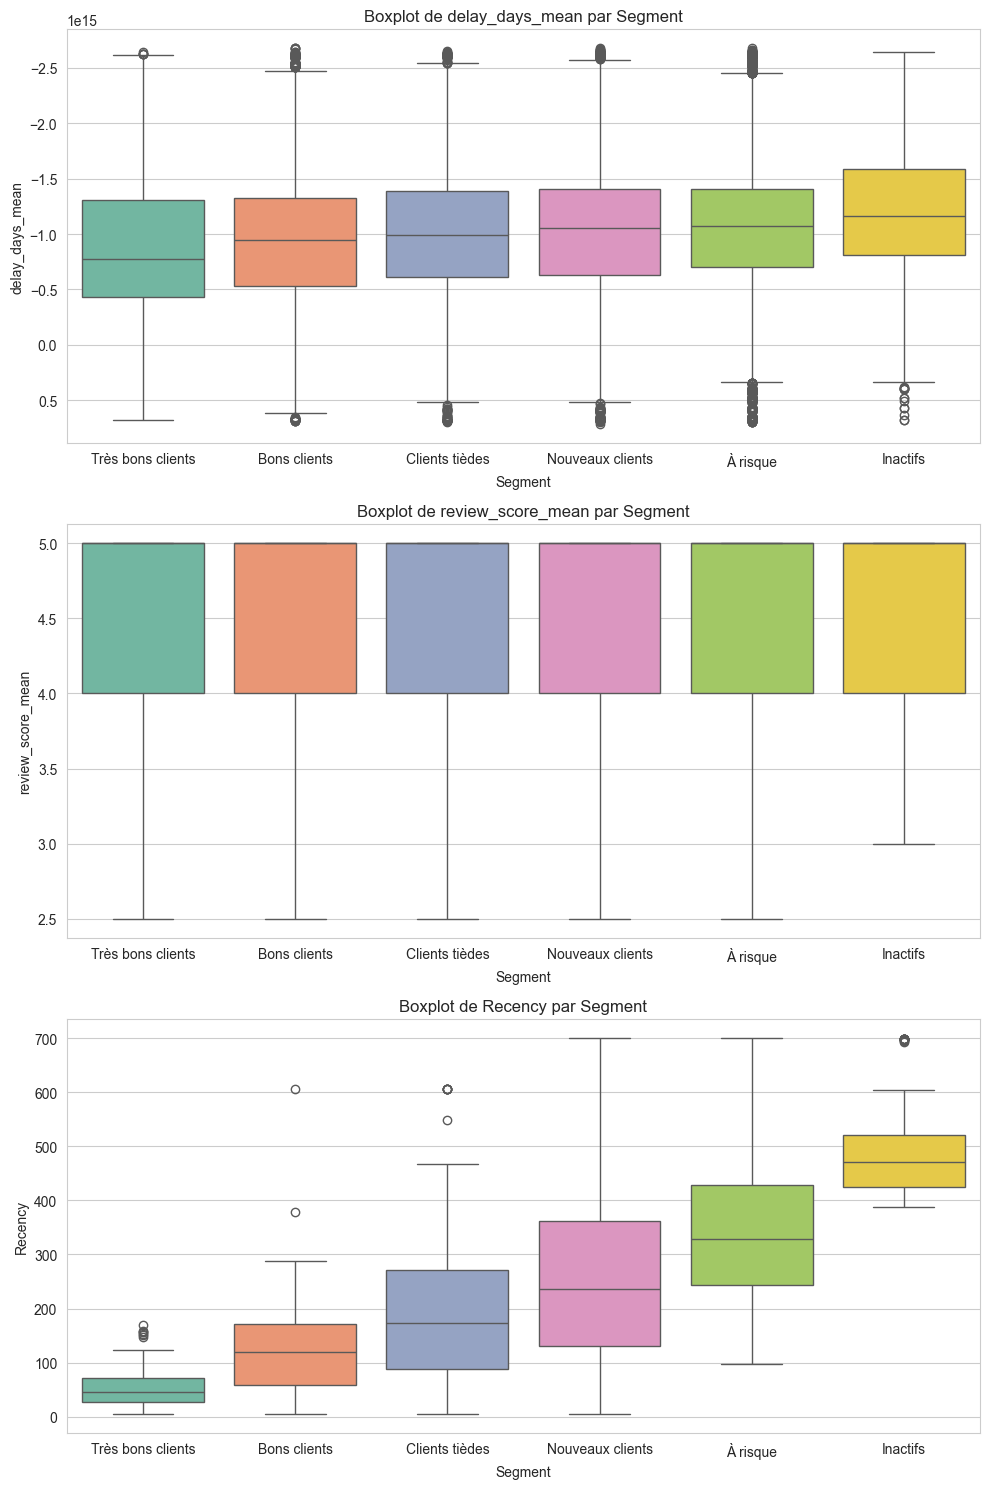

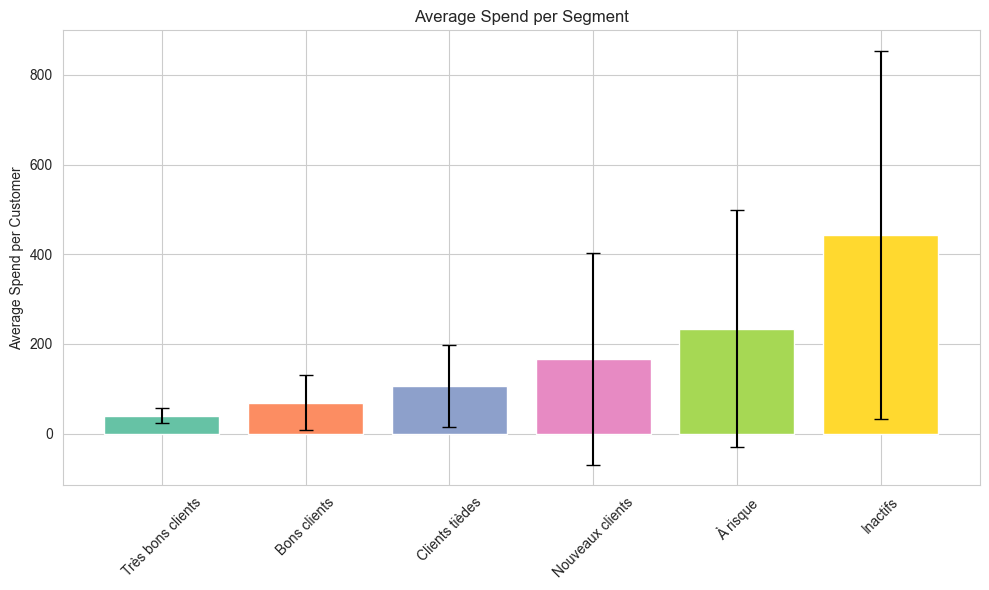

In [24]:
plot_boxplots(df_no_outliers, numeric_cols, 'Segment', segment_order)

summary = clients_df.groupby('Segment')['order_total_sum'].agg(['mean', 'std']).reindex(segment_order).reset_index()

plt.figure(figsize=(10,6))
plt.bar(
    summary['Segment'],
    summary['mean'],
    yerr=summary['std'],
    capsize=5,
    color=sns.color_palette('Set2', len(summary))
)
plt.ylabel('Average Spend per Customer')
plt.title('Average Spend per Segment')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


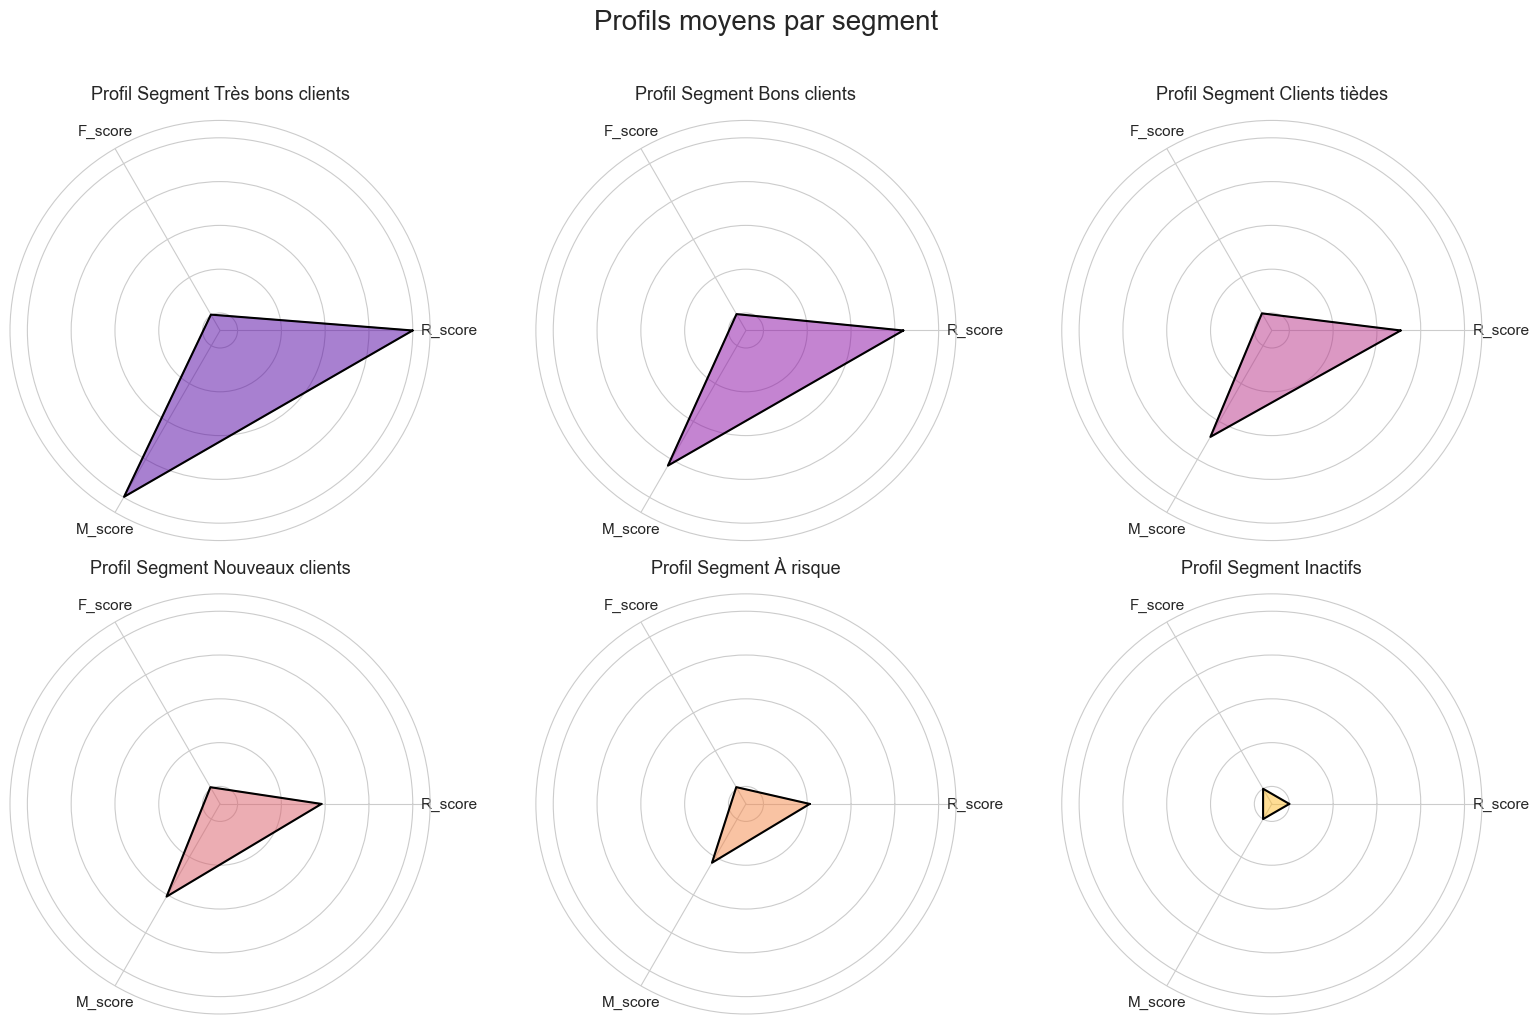

In [ ]:
rfm_cols = ["R_score", "F_score", "M_score"]

grouped = df_no_outliers.groupby("Segment")[rfm_cols].mean()

global_min = grouped[rfm_cols].min().min()
global_max = grouped[rfm_cols].max().max()
padding = (global_max - global_min) * 0.1
global_min -= padding
global_max += padding

labels = rfm_cols
num_vars = len(labels)

angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += [angles[0]]

fig, axes = plt.subplots(2, 3, subplot_kw=dict(polar=True), figsize=(16, 10))
axes = axes.flatten()

palette = sns.color_palette("plasma", n_colors=len(grouped))

for i, segment in enumerate(segment_order):
    if segment not in grouped.index:
        continue
    
    row = grouped.loc[segment]
    values = row.tolist() + [row.tolist()[0]]
    
    ax = axes[i]
    color = palette[i % len(palette)]
    
    ax.plot(angles, values, color='black', linewidth=1.5)
    ax.fill(angles, values, color=color, alpha=0.5)

    # enforce same radial scale
    ax.set_rlim(global_min, global_max)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels, fontsize=11)
    ax.set_yticklabels([])
    ax.set_title(f"Profil Segment {segment}", size=13, pad=15)

for j in range(len(segment_order), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Profils moyens par segment", fontsize=20, y=1.02)
plt.tight_layout()
plt.show()


## Quick PCA & T-SNE

In [ ]:
clients_df[["delay_days_mean","order_total_sum","Frequency","review_score_mean", "Recency"]]

,delay_days_mean,order_total_sum,Frequency,review_score_mean,Recency
customer_unique_id,,,,,
0000366f3b9a7992bf8c76cfdf3221e2,-5 days +20:48:37,141.90,1,5.0,116
0000b849f77a49e4a4ce2b2a4ca5be3f,-5 days +18:02:42,27.19,1,4.0,119
0000f46a3911fa3c0805444483337064,-2 days +14:38:47,86.22,1,3.0,542
0000f6ccb0745a6a4b88665a16c9f078,-12 days +21:23:05,43.62,1,4.0,326
0004aac84e0df4da2b147fca70cf8255,-8 days +23:08:56,196.89,1,5.0,293
...,...,...,...,...,...
fffcf5a5ff07b0908bd4e2dbc735a684,-27 days +09:22:00,2067.42,1,5.0,452
fffea47cd6d3cc0a88bd621562a9d061,-3 days +22:28:20,84.58,1,4.0,267
ffff371b4d645b6ecea244b27531430a,-30 days +12:45:04,112.46,1,5.0,573


In [ ]:
X_base = clients_df[["delay_days_mean","order_total_sum","Frequency","review_score_mean", "Recency"]]

X_base['delay_days_mean'] = X_base['delay_days_mean'].dt.total_seconds() / (24*60*60)

X_base = X_base.dropna()
X_base = X_base.sample(n=12000, random_state=42)
X = X_base.values

std_scale = preprocessing.StandardScaler()
std_scale_X = std_scale.fit(X)
X_scaled = std_scale.transform(X)

C:\Users\jfurs\AppData\Local\Temp\ipykernel_3272\4200452145.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_base['delay_days_mean'] = X_base['delay_days_mean'].dt.total_seconds() / (24*60*60)


In [ ]:
pca = PCA()
pca.fit(X_scaled)
pca_data = pca.transform(X_scaled)

per_var = np.round(pca.explained_variance_ratio_* 100, decimals=1)

labels = ['PC' + str(x) for x in range(1, len(per_var)+1)]

print(f"PC1 et PC2 représentent {np.round(per_var[0] + per_var[1],2)} % de la variance expliquée.")

PC1 et PC2 représentent 47.7 % de la variance expliquée.


In [ ]:
pca_df = pd.DataFrame(X_scaled, columns=labels)

In [ ]:
tsne = TSNE(n_components=2, perplexity=30, learning_rate=200, max_iter=1000, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)

# CLUSTERING

## KMeans

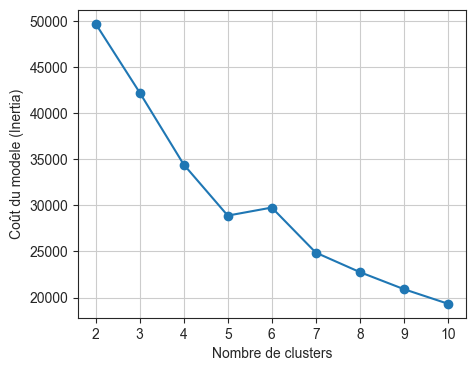

In [ ]:
inertia = []

sns.set_style('ticks')

k_range=range(2,11)
for k in k_range:
    model=KMeans(n_clusters=k).fit(X_scaled)
    inertia.append(model.inertia_)

fig = plt.figure(figsize=(5,4))
plt.plot(k_range,inertia, marker='o', linestyle='-')
plt.xlabel('Nombre de clusters')
plt.ylabel('Coût du modele (Inertia)')
plt.grid()
plt.show()

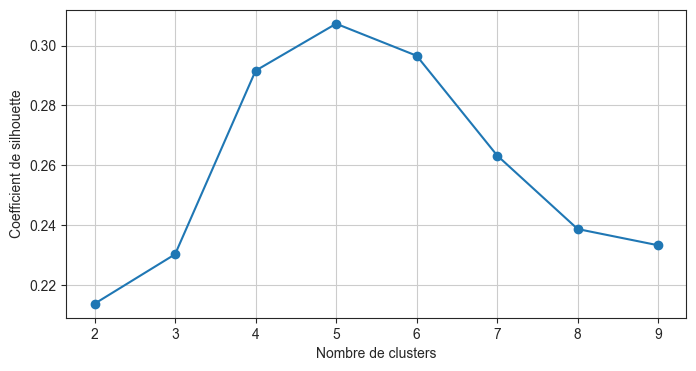

[0.213727720653514,
 0.23025150373098285,
 0.2915970611266887,
 0.30727714604989104,
 0.2965763547216457,
 0.263247032545041,
 0.23867582938793117,
 0.2332504045229195]

In [ ]:
sns.set_style('ticks')

tab_silhouette = []
k_range = range(2,10)
for k in k_range:
    model=KMeans(n_clusters=k)
    cluster_labels=model.fit_predict(X_scaled)
    tab_silhouette.append(silhouette_score(X_scaled, cluster_labels, sample_size=10000, random_state=42))

fig = plt.figure(figsize=(8,4))
plt.plot(k_range, tab_silhouette, marker='o')
plt.xlabel('Nombre de clusters')
plt.ylabel('Coefficient de silhouette')
plt.grid()
plt.show()

tab_silhouette

In [ ]:
k = 6 
kmeans = KMeans(n_clusters=k, random_state=42)
kmeans.fit(X_scaled)

kmeans_labels = kmeans.labels_
print(kmeans_labels)

[2 2 0 ... 5 5 5]


### Analyse 6 clusters KMeans

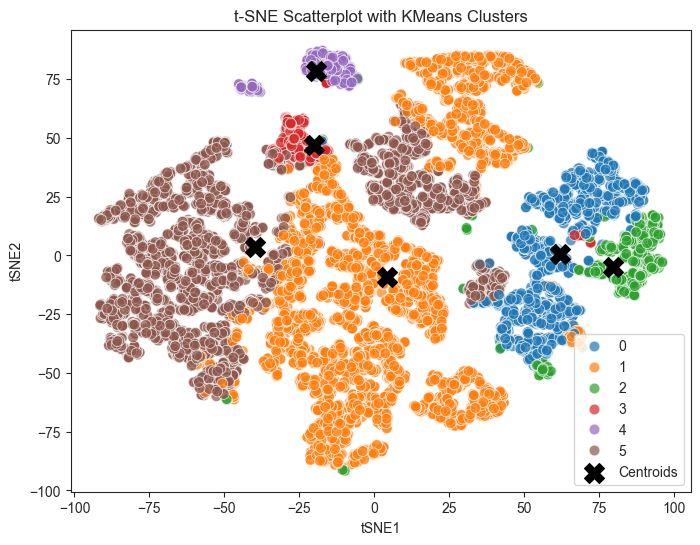

In [ ]:
tsne_df = pd.DataFrame({
    "tSNE1": X_tsne[:, 0],
    "tSNE2": X_tsne[:, 1],
    "kmeans_cluster": kmeans_labels
})
plt.figure(figsize=(8, 6))
sns.scatterplot(
    x="tSNE1", y="tSNE2",
    hue="kmeans_cluster",
    palette="tab10",
    data=tsne_df,
    s=60,
    alpha=0.7
)

centroids = tsne_df.groupby("kmeans_cluster")[["tSNE1", "tSNE2"]].mean()
plt.scatter(
    centroids["tSNE1"], centroids["tSNE2"],
    c="black", marker="X", s=200, label="Centroids"
)

plt.title("t-SNE Scatterplot with KMeans Clusters")
plt.legend()
plt.show()

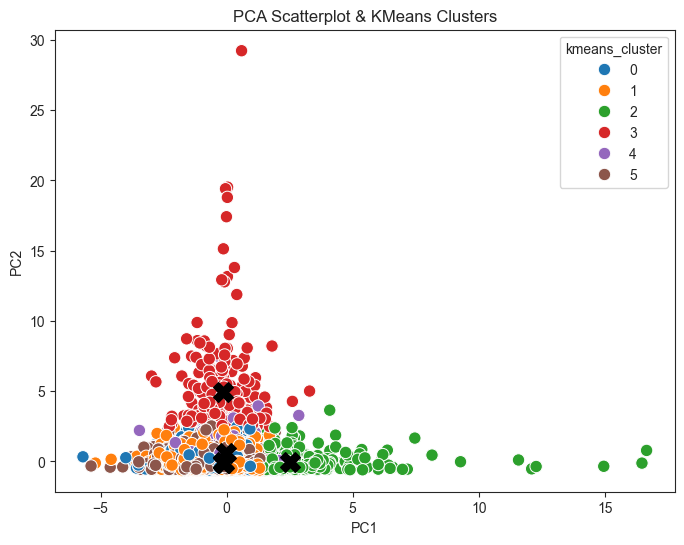

In [ ]:
kmeans_pca_df = pca_df.copy()
kmeans_pca_df["kmeans_cluster"] = kmeans_labels

plt.figure(figsize=(8, 6))
sns.scatterplot(x="PC1", y="PC2", hue="kmeans_cluster", palette="tab10", data=kmeans_pca_df, s=80)

centroids = kmeans_pca_df.groupby("kmeans_cluster")[["PC1", "PC2"]].mean()

plt.scatter(
    centroids["PC1"], centroids["PC2"],
    c="black", marker="X", s=200, label="Centroids")

plt.title("PCA Scatterplot & KMeans Clusters")
plt.show()

In [ ]:
cluster_sizes = kmeans_pca_df['kmeans_cluster'].value_counts().sort_index()
print("Taille des KMeans Clusters :")
for cluster, size in cluster_sizes.items():
    print(f"Taille Cluster {cluster} : {size}")

Taille des KMeans Clusters :
Taille Cluster 0 : 1601
Taille Cluster 1 : 5241
Taille Cluster 2 : 567
Taille Cluster 3 : 251
Taille Cluster 4 : 340
Taille Cluster 5 : 4000


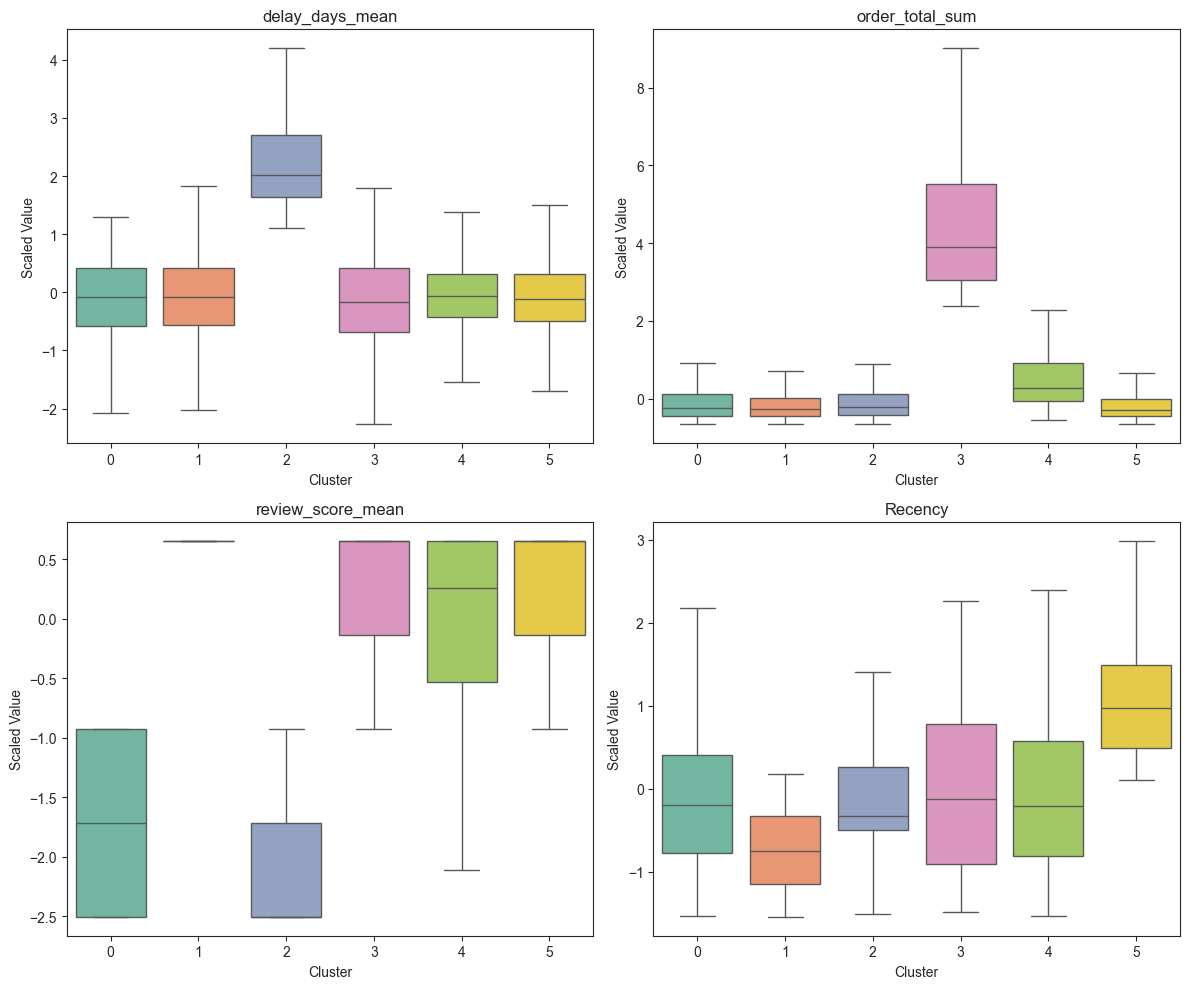

In [ ]:
# Scaling

df_kmeans_prep = X_base[["delay_days_mean", "order_total_sum", "review_score_mean", "Recency"]]
X_kmeans_scaled = std_scale.fit_transform(df_kmeans_prep)
df_kmeans_scaled = pd.DataFrame(X_kmeans_scaled, columns=df_kmeans_prep.columns)
df_kmeans_scaled['kmeans_cluster'] = kmeans_labels

df_melted = df_kmeans_scaled.melt(id_vars="kmeans_cluster", 
                                  var_name="Variable", 
                                  value_name="Value")

variables = df_melted["Variable"].unique()
n_vars = len(variables)

n_cols = 2
n_rows = math.ceil(n_vars / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 5 * n_rows))
sns.set_style("whitegrid")

axes = axes.flatten()

for i, var in enumerate(variables):
    ax = axes[i]
    sns.boxplot(x="kmeans_cluster", y="Value", 
                data=df_melted[df_melted["Variable"] == var],
                palette="Set2", ax=ax, showfliers=False)
    ax.set_title(var)
    ax.set_xlabel("Cluster")
    ax.set_ylabel("Scaled Value")

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## Clustering Ascendant Hierarchique

In [ ]:
Z = linkage(X_scaled, method = 'ward', metric='euclidean')

# Z[:,0] = index du 1er cluster fusionné
# Z[:,1] = index du 2nd cluster fusionné
# Z[:,2] = distance entre ces deux groupes lorsqu'ils ont été fusionnés
# Z[:,3] = nombre d'éléments dans le nouveau groupe formé par la fusion

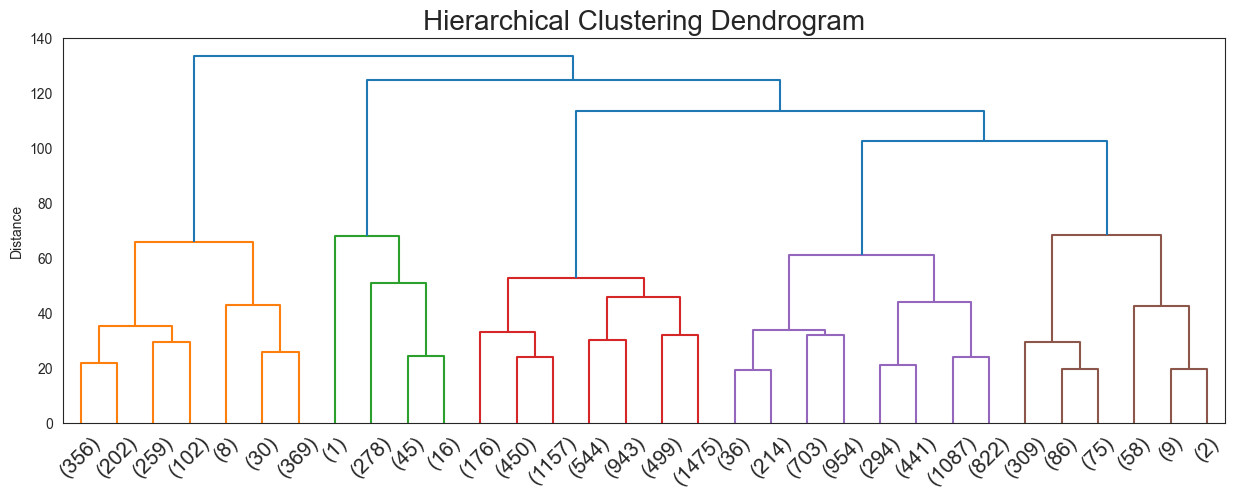

In [ ]:
fig =plt.figure(figsize=(15,5))
sns.set_style('white')

labels = list(X_base.index)
labels = ["(1)" if str(x).startswith("8d50f5eadf") else str(x) for x in labels]

dendrogram(Z, labels=labels, p=32, truncate_mode='lastp', leaf_font_size=15, orientation='top')
# plt.axhline(y=13, color='grey', linestyle='--')
# plt.axhline(y=13.8, color='grey', linestyle='--')
plt.title('Hierarchical Clustering Dendrogram', fontsize=20)
plt.ylabel('Distance')
plt.show()

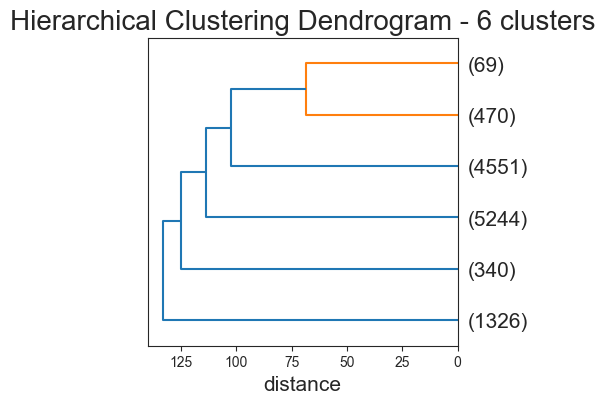

In [ ]:
sns.set_style('ticks')

fig = plt.figure(figsize=(4,4))
plt.title('Hierarchical Clustering Dendrogram - 6 clusters', fontsize=20)
plt.xlabel('distance', fontsize=15)
dendrogram(Z, labels = X_base.index, p=6, truncate_mode='lastp', leaf_font_size=15, orientation='left')
plt.show()

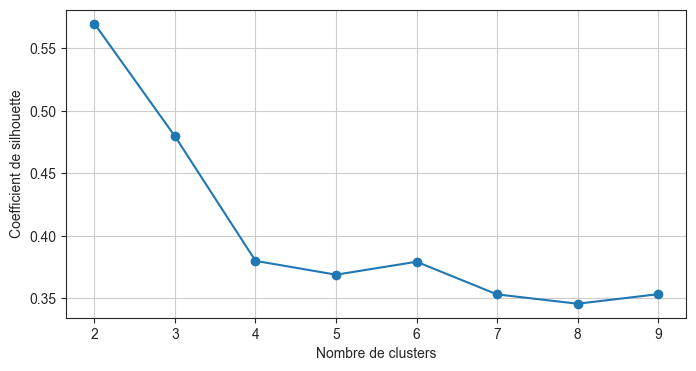

[0.5696982939029506,
 0.47965173241875736,
 0.38000036989992836,
 0.3689316149558711,
 0.37928831797629836,
 0.35318321138677333,
 0.34571362891662877,
 0.35333849024479186]

In [ ]:
sns.set_style('ticks')

tab_silhouette = []
k_range = range(2,10)

for k in k_range:
    ach_model = AgglomerativeClustering(n_clusters = k)
    ach_clusters = ach_model.fit_predict(Z)
    tab_silhouette.append(silhouette_score(Z, ach_clusters,  sample_size=15000, random_state=42))

fig = plt.figure(figsize=(8,4))
plt.plot(k_range,tab_silhouette,marker='o')
plt.xlabel('Nombre de clusters')
plt.ylabel('Coefficient de silhouette')
plt.grid()
plt.show()

tab_silhouette

### Analyse clusters ACH

In [ ]:
ach_labels = fcluster(Z, 6, criterion='maxclust')

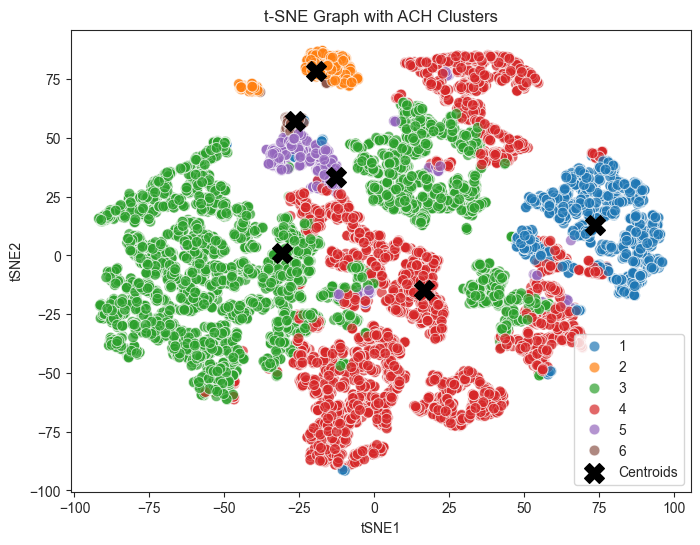

In [ ]:
tsne_df = pd.DataFrame({
    "tSNE1": X_tsne[:, 0],
    "tSNE2": X_tsne[:, 1],
    "ach_cluster": ach_labels
})
plt.figure(figsize=(8, 6))
sns.scatterplot(
    x="tSNE1", y="tSNE2",
    hue="ach_cluster",
    palette="tab10",
    data=tsne_df,
    s=60,
    alpha=0.7
)

centroids = tsne_df.groupby("ach_cluster")[["tSNE1", "tSNE2"]].mean()
plt.scatter(
    centroids["tSNE1"], centroids["tSNE2"],
    c="black", marker="X", s=200, label="Centroids"
)

plt.title("t-SNE Graph with ACH Clusters")
plt.legend()
plt.show()

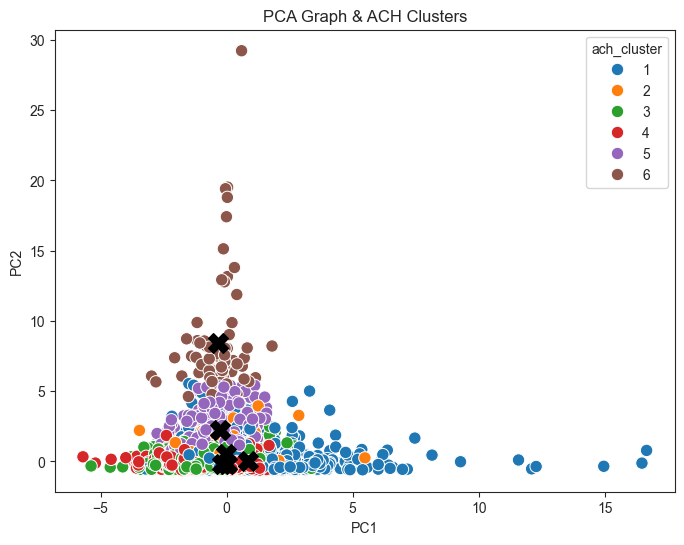

In [ ]:
ach_pca_df = pca_df.copy()
ach_pca_df["ach_cluster"] = ach_labels

plt.figure(figsize=(8, 6))
sns.scatterplot(x="PC1", y="PC2", hue="ach_cluster", palette="tab10", data=ach_pca_df, s=80)

centroids = ach_pca_df.groupby("ach_cluster")[["PC1", "PC2"]].mean()

plt.scatter(
    centroids["PC1"], centroids["PC2"],
    c="black", marker="X", s=200, label="Centroids")

plt.title("PCA Graph & ACH Clusters")
plt.show()

In [ ]:
cluster_sizes = ach_pca_df['ach_cluster'].value_counts().sort_index()
print("Taille des ACH Clusters :")
for cluster, size in cluster_sizes.items():
    print(f"Taille Cluster {cluster} : {size}")

Taille des ACH Clusters :
Taille Cluster 1 : 1326
Taille Cluster 2 : 340
Taille Cluster 3 : 5244
Taille Cluster 4 : 4551
Taille Cluster 5 : 470
Taille Cluster 6 : 69


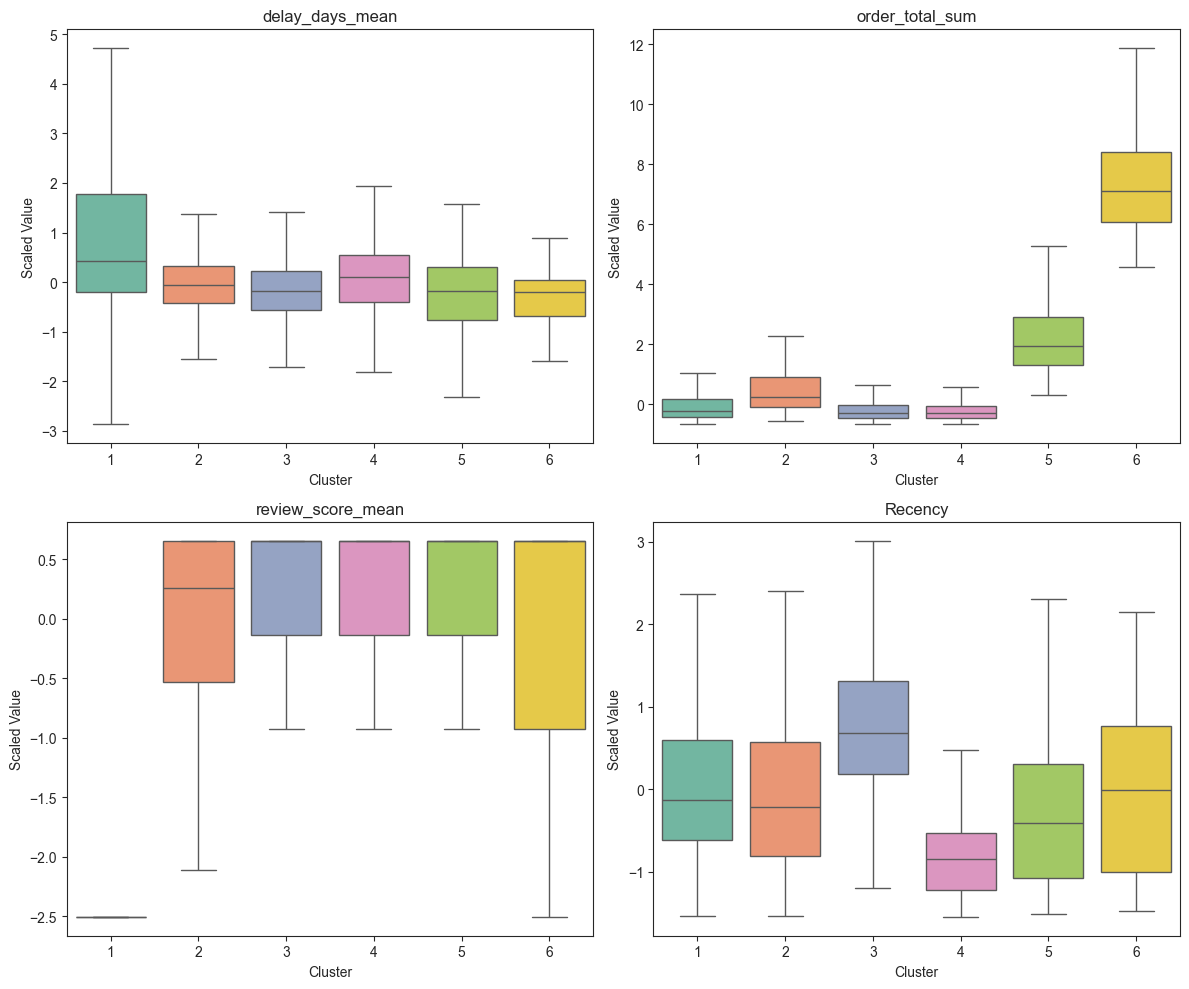

In [ ]:
# Scaling
df_ach_prep = X_base[["delay_days_mean", "order_total_sum", "review_score_mean", "Recency"]]
X_ach_scaled = std_scale.fit_transform(df_ach_prep)
df_ach_scaled = pd.DataFrame(X_ach_scaled, columns=df_ach_prep.columns)
df_ach_scaled['ach_cluster'] = ach_labels

df_melted = df_ach_scaled.melt(id_vars="ach_cluster", 
                               var_name="Variable", 
                               value_name="Value")

variables = df_melted["Variable"].unique()
n_vars = len(variables)

n_cols = 2
n_rows = math.ceil(n_vars / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 5 * n_rows))
sns.set_style("whitegrid")

axes = axes.flatten()

for i, var in enumerate(variables):
    ax = axes[i]
    sns.boxplot(x="ach_cluster", y="Value", data=df_melted[df_melted["Variable"] == var],
                palette="Set2", ax=ax, showfliers=False)
    ax.set_title(var)
    ax.set_xlabel("Cluster")
    ax.set_ylabel("Scaled Value")

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()